# Lazada Thailand Health & Wellness Products Analysis

**Business question:** If you were selling health and wellness products on Lazada Thailand, which categories and price points move the most volume, and where are the successful sellers based?

**Interactive dashboard:** [Tableau Public](https://public.tableau.com/views/LazadaThailandHealthProductsDashboard/LazadaDashboard)

This notebook covers:
1. Two data-quality problems in the raw scrape, and how they were fixed
2. The cleaned, one-row-per-product dataset used by the dashboard
3. The analysis behind each dashboard chart

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)
ACCENT, MUTED = '#2E5C8A', '#B8C4CE'

## 1. Load the raw data

In [2]:
raw = pd.read_csv('health_and_wellness_cleaned.csv')
print(f"Rows: {len(raw):,}")
print(f"Unique product IDs: {raw['Id'].nunique():,}")
raw.head()

Rows: 68,499
Unique product IDs: 2,497


,Id,Section,Name,Price,Total Sold,Total Reviews,Shop Location
0,4799179886,Acne Care,DHC Vitamin B-Mix วิตามินบีรวม (สำหรับ 20 วัน),฿75.00,NaN,NaN,Pathum Thani
1,4795171651,Acne Care,ซิงค์ Vistra Zinc วิสทร้า ซิงค์ 15 มก. ขนาด 20 แคปซูล,฿79.00,NaN,NaN,Chiang Mai
2,4790242641,Acne Care,Blackmores แบลคมอร์ส Bio Zinc A Chelate (90 Tabs) หมดอา...,฿224.00,NaN,NaN,Surin
3,4789940606,Acne Care,1แถม1 กลูต้าวิตมี กลูต้าส้มเลือด Gluta With Me ช่วยให้ผิ...,฿290.00,NaN,NaN,Udon Thani
4,4787161067,Acne Care,🎌 DHC Vitamin B-Mix Persistent วิตามินบีรวม แบบละลายช้า ...,฿149.00,NaN,NaN,Bangkok


## 2. Data-quality issue 1: the same product appears many times

The file has 68,499 rows but only 2,497 unique product IDs. The scraper captured each listing repeatedly, so any sum over the raw rows counts the same product many times.

In [3]:
repeats = raw['Id'].value_counts()
print(f"Average rows per product: {repeats.mean():.1f}")
print(f"Most rows for one product: {repeats.max()}")
print(f"Fully identical duplicate rows: {raw.duplicated().sum():,}")

Average rows per product: 27.4
Most rows for one product: 115
Fully identical duplicate rows: 65,877


## 3. Data-quality issue 2: sales numbers were parsed incorrectly

`Total Sold` is stored as Thai text such as `5,786 ชิ้น` ("5,786 pieces"). A regex that grabs the first run of digits (`\d+`) stops at the comma, so 5,786 becomes 5. The best-selling products were undercounted the most.

The fixed parser removes thousands separators, handles `k`, and flags values shown as `9,999+` or `100k+` as **lower bounds**. Missing values stay missing (not 0), because a listing without a sales counter is not the same as a listing with zero sales.

In [4]:
def old_parse(text):
    match = re.search(r'\d+', str(text))
    return int(match.group()) if match else 0

def parse_count(text):
    """Return (value, is_lower_bound). '5,786 ชิ้น' -> 5786; '9,999+ ชิ้น' -> (9999, True); '100k+' -> (100000, True)."""
    if pd.isna(text):
        return np.nan, False
    s = str(text)
    m = re.search(r'([\d,]+(?:\.\d+)?)\s*(k)?', s, re.I)
    if not m:
        return np.nan, False
    value = float(m.group(1).replace(',', ''))
    if m.group(2):
        value *= 1000
    return value, '+' in s

examples = ['5,786 ชิ้น', '9,999+ ชิ้น', '100k+ ชิ้น', '173 ชิ้น']
pd.DataFrame({'raw text': examples,
              'old parser': [old_parse(t) for t in examples],
              'fixed parser': [parse_count(t)[0] for t in examples]})

,raw text,old parser,fixed parser
0,"5,786 ชิ้น",5,5786.0
1,"9,999+ ชิ้น",9,9999.0
2,100k+ ชิ้น,100,100000.0
3,173 ชิ้น,173,173.0


## 4. Build the clean dataset

Steps:
- Drop exact duplicate rows
- Parse price, units sold and reviews correctly
- Keep **one row per product**: the snapshot with the highest units sold (Lazada's counter is cumulative), ties broken by reviews
- Add a price band, an estimated revenue (units sold × current price) and a seller region group

In [5]:
df = raw.drop_duplicates().copy()
df['Price_THB'] = (df['Price'].str.replace('฿', '', regex=False)
                              .str.replace(',', '', regex=False).astype(float))
sold = df['Total Sold'].apply(parse_count)
df['Units_Sold'] = [v for v, _ in sold]
df['Sold_Capped'] = [c for _, c in sold]
df['Reviews'] = [v for v, _ in df['Total Reviews'].apply(parse_count)]

df = (df.sort_values(['Id', 'Units_Sold', 'Reviews'], ascending=[True, False, False], na_position='last')
        .drop_duplicates('Id', keep='first'))

df['Has_Sales_Data'] = df['Units_Sold'].notna()
df['Est_Revenue_THB'] = df['Units_Sold'] * df['Price_THB']
bands = ['<฿100', '฿100–299', '฿300–499', '฿500–999', '฿1,000+']
df['Price_Band'] = pd.cut(df['Price_THB'], bins=[0, 100, 300, 500, 1000, np.inf], labels=bands, right=False)
df['Shop_Location'] = df['Shop Location'].fillna('Unknown')
greater_bkk = ['Bangkok', 'Nonthaburi', 'Pathum Thani', 'Samut Prakan', 'Samut Sakhon', 'Nakhon Pathom']
df['Region_Group'] = np.where(df['Shop_Location'].isin(greater_bkk), 'Greater Bangkok',
                              np.where(df['Shop_Location'] == 'Unknown', 'Unknown', 'Other provinces'))

clean = df[['Id', 'Name', 'Section', 'Price_THB', 'Price_Band', 'Units_Sold', 'Sold_Capped', 'Has_Sales_Data',
            'Reviews', 'Est_Revenue_THB', 'Shop_Location', 'Region_Group']].rename(
            columns={'Id': 'Product_ID', 'Name': 'Product_Name', 'Section': 'Category'})
clean.to_csv('lazada_health_products_clean.csv', index=False, encoding='utf-8-sig')

print(f"Products: {len(clean):,}")
print(f"Products showing a sales counter: {clean['Has_Sales_Data'].sum():,} ({clean['Has_Sales_Data'].mean():.0%})")
print(f"Products capped at 9,999+ or 100k+: {clean['Sold_Capped'].sum()}")

Products: 2,497
Products showing a sales counter: 1,336 (54%)
Products capped at 9,999+ or 100k+: 52


## 5. Headline numbers (dashboard KPI row)

In [6]:
kpis = pd.Series({
    'Products': f"{len(clean):,}",
    'Units sold (lower bound)': f"{clean['Units_Sold'].sum():,.0f}",
    'Estimated revenue (THB)': f"฿{clean['Est_Revenue_THB'].sum() / 1e6:,.1f}M",
    'Median price (THB)': f"฿{clean['Price_THB'].median():,.0f}",
})
kpis.to_frame('value')

,value
Products,"2,497"
Units sold (lower bound),"1,912,640"
Estimated revenue (THB),฿404.1M
Median price (THB),฿299


## 6. Which categories sell the most?

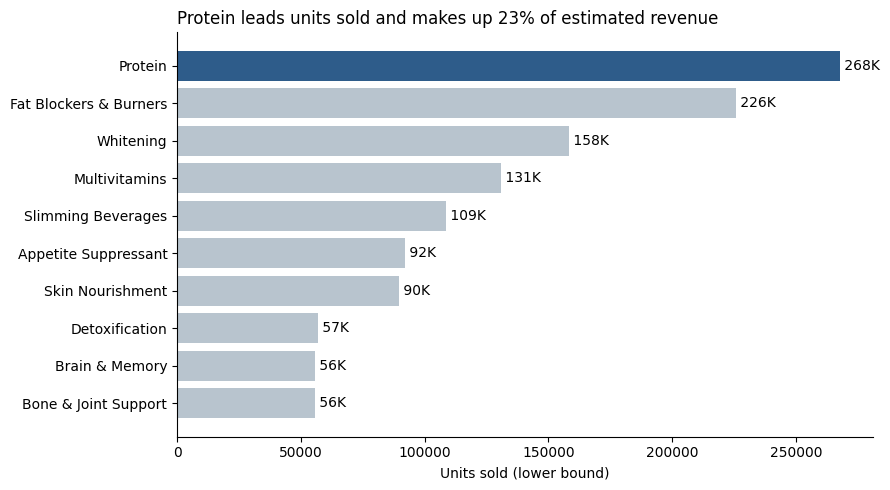

,products,units,revenue,median_price,revenue_share
Category,,,,,
Protein,84,"267,828","฿94,749,907",฿740,23.4%
Fat Blockers & Burners,95,"225,586","฿14,712,750",฿175,3.6%
Whitening,81,"158,392","฿24,735,543",฿195,6.1%
Multivitamins,79,"131,021","฿7,357,757",฿185,1.8%
Slimming Beverages,79,"108,598","฿20,921,711",฿240,5.2%
Appetite Suppressant,81,"92,097","฿13,523,945",฿259,3.3%
Skin Nourishment,97,"89,704","฿21,235,311",฿200,5.3%
Detoxification,110,"56,789","฿11,018,819",฿332,2.7%
Brain & Memory,80,"55,872","฿11,032,577",฿249,2.7%


In [7]:
cat = (clean.groupby('Category')
            .agg(products=('Product_ID', 'count'), units=('Units_Sold', 'sum'),
                 revenue=('Est_Revenue_THB', 'sum'), median_price=('Price_THB', 'median'))
            .sort_values('units', ascending=False))
cat['revenue_share'] = cat['revenue'] / cat['revenue'].sum()

top10 = cat.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10.index, top10['units'], color=[ACCENT if c == 'Protein' else MUTED for c in top10.index])
for y, v in enumerate(top10['units']):
    ax.text(v, y, f' {v/1e3:,.0f}K', va='center')
ax.set_title(f"Protein leads units sold and makes up {cat.loc['Protein', 'revenue_share']:.0%} of estimated revenue", loc='left')
ax.set_xlabel('Units sold (lower bound)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

cat.head(10).style.format({'units': '{:,.0f}', 'revenue': '฿{:,.0f}', 'median_price': '฿{:,.0f}', 'revenue_share': '{:.1%}'})

## 7. Which price points move the volume?

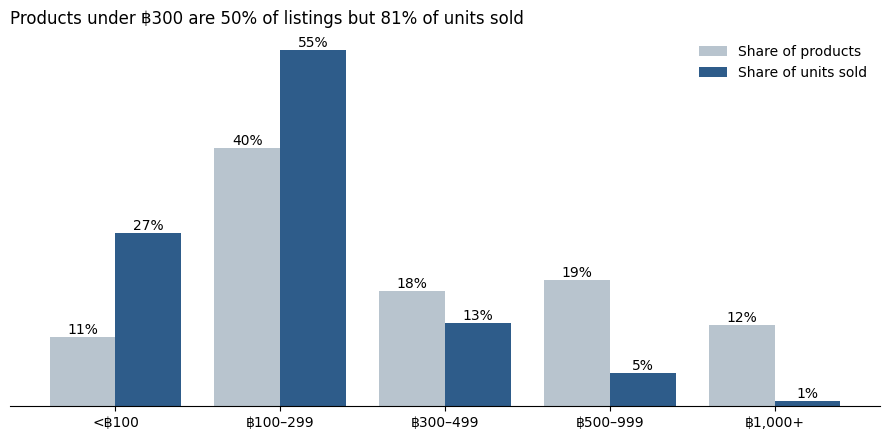

In [8]:
band = (clean.groupby('Price_Band', observed=True)
             .agg(products=('Product_ID', 'count'), units=('Units_Sold', 'sum')))
band['product_share'] = band['products'] / band['products'].sum()
band['units_share'] = band['units'] / band['units'].sum()

under_300 = clean['Price_THB'] < 300
share_products = under_300.mean()
share_units = clean.loc[under_300, 'Units_Sold'].sum() / clean['Units_Sold'].sum()

x = np.arange(len(band))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - 0.2, band['product_share'], 0.4, color=MUTED, label='Share of products')
ax.bar(x + 0.2, band['units_share'], 0.4, color=ACCENT, label='Share of units sold')
for i, (p, u) in enumerate(zip(band['product_share'], band['units_share'])):
    ax.text(i - 0.2, p, f'{p:.0%}', ha='center', va='bottom')
    ax.text(i + 0.2, u, f'{u:.0%}', ha='center', va='bottom')
ax.set_xticks(x, band.index)
ax.set_yticks([])
ax.set_title(f'Products under ฿300 are {share_products:.0%} of listings but {share_units:.0%} of units sold', loc='left')
ax.legend(frameon=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Where are the top sellers based?

`Shop Location` is the **seller's** province, not the buyer's.

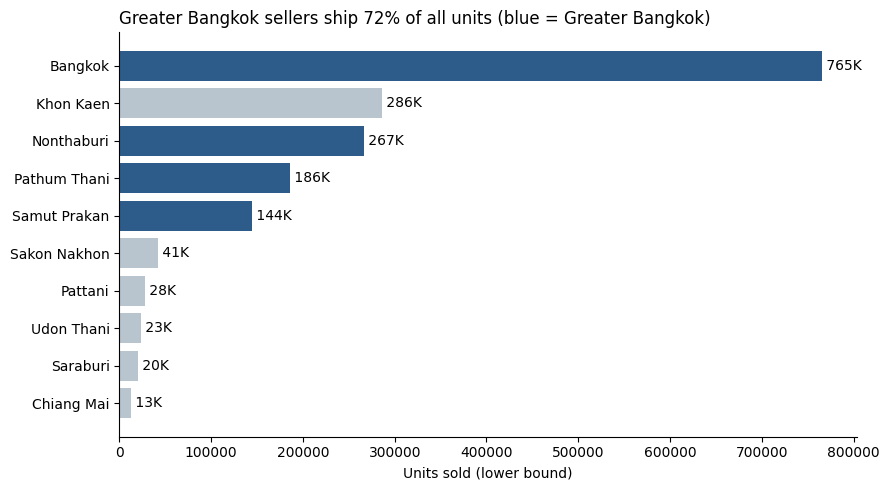

Khon Kaen is #2, but its top 2 products (one brand) account for 70% of its units.


In [9]:
loc = clean.groupby(['Shop_Location', 'Region_Group'])['Units_Sold'].sum().sort_values(ascending=False).reset_index()
region_share = clean.groupby('Region_Group')['Units_Sold'].sum() / clean['Units_Sold'].sum()

top_loc = loc.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_loc['Shop_Location'], top_loc['Units_Sold'],
        color=[ACCENT if g == 'Greater Bangkok' else MUTED for g in top_loc['Region_Group']])
for y, v in enumerate(top_loc['Units_Sold']):
    ax.text(v, y, f' {v/1e3:,.0f}K', va='center')
ax.set_title(f"Greater Bangkok sellers ship {region_share['Greater Bangkok']:.0%} of all units (blue = Greater Bangkok)", loc='left')
ax.set_xlabel('Units sold (lower bound)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

kk = clean[clean['Shop_Location'] == 'Khon Kaen'].nlargest(2, 'Units_Sold')
print(f"Khon Kaen is #2, but its top 2 products (one brand) account for "
      f"{kk['Units_Sold'].sum() / clean.loc[clean['Shop_Location'] == 'Khon Kaen', 'Units_Sold'].sum():.0%} of its units.")

## 9. Top 10 products

Five products show `100k+` and 47 show `9,999+`, so exact ranks within those groups are unknown. Ties are broken by review count, which tracks sales closely (see section 10).

In [10]:
top_products = clean.sort_values(['Units_Sold', 'Reviews'], ascending=False).head(10)[['Product_Name', 'Category', 'Price_THB', 'Units_Sold', 'Sold_Capped', 'Reviews', 'Shop_Location']]
top_products['Units_Sold'] = [f"{v:,.0f}+" if c else f"{v:,.0f}" for v, c in zip(top_products['Units_Sold'], top_products['Sold_Capped'])]
top_products.drop(columns='Sold_Capped').reset_index(drop=True)

,Product_Name,Category,Price_THB,Units_Sold,Reviews,Shop_Location
0,MATELL Soy Protein Isolate Plant Based ถั่วเหลือง ซอย โป...,Protein,249.0,"100,000+",26177.0,Khon Kaen
1,Apple Herb Detox [10 แคปซูล/ซอง] / Luxi Manow Detox [5 แ...,Fat Blockers & Burners,9.0,"100,000+",11389.0,Nonthaburi
2,MATELL Whey Protein Isolate เวย์ โปรตีน ไอโซเลท Non Soy ...,Protein,449.0,"100,000+",11367.0,Khon Kaen
3,Collagen plus Gold Princess (คอลลาเจน พลัส บรรจุ 40 เม็ด),Whitening,139.0,"100,000+",10746.0,Samut Prakan
4,Clover Plus VH Collagen Peptide Vitamin/ DB Collagen Pep...,Multivitamins,13.0,"100,000+",8665.0,Bangkok
5,VISTRA Zinc 15mg ( 45 caps) - วิสทร้า ซิงก์ 15 มก. ( 45...,Multivitamins,204.0,"9,999+",7216.0,Chachoengsao
6,Vitaccino coffee เกรดเอ มีสติกเกอร์ LIDA กาแฟลดน้ำหนัก ก...,Food Supplement,118.0,"9,999+",6800.0,Bangkok
7,MATELL Acerola Cherry Vitamin C 1000 mg 50 Tablets อะเซโ...,Immunity,79.0,"9,999+",6460.0,Khon Kaen
8,MATELL Plant-Based Protein Isolate แพลนต์เบสด์ ไอโซเลท โ...,Protein,449.0,"9,999+",6282.0,Khon Kaen
9,(ซื้อ 1 แถม 1) GIVE-ME Berry กีฟมีเบอร์รี่ พลัสไฟเบอร์ (...,Detoxification,129.0,"9,999+",5996.0,Bangkok


## 10. Do reviews track sales? Does price?

In [11]:
both = clean.dropna(subset=['Units_Sold', 'Reviews'])
print(f"Reviews vs units sold (Spearman): {both['Reviews'].corr(both['Units_Sold'], method='spearman'):.2f}")
print(f"Price vs reviews (Spearman):      {clean['Price_THB'].corr(clean['Reviews'], method='spearman'):.2f}")

Reviews vs units sold (Spearman): 0.96
Price vs reviews (Spearman):      -0.24


## Key findings

1. **Protein is the biggest category** by both units sold and estimated revenue (23% of estimated revenue). Fat Blockers & Burners and Whitening follow on units.
2. **Low prices drive volume.** Products under ฿300 are about half the listings but over 80% of units sold. Products above ฿1,000 are 12% of listings but about 1% of units.
3. **Sellers cluster in Greater Bangkok**, which ships about 72% of units. Khon Kaen ranks #2, but mostly because of one brand's two protein products.
4. **Reviews are a strong proxy for sales** (Spearman ≈ 0.96), which is useful because 46% of listings do not show a sales counter. Cheaper products tend to have more reviews (weak negative correlation with price).

## Limitations
- Units sold are cumulative lifetime counts with no dates, so this shows which products have sold the most, not current trends.
- 52 products show only `9,999+` or `100k+`, so totals are lower bounds.
- Revenue is estimated from today's price and ignores discounts and price changes.
- The dataset is a scrape of listings in 30 health categories, not all of Lazada.